<a href="https://colab.research.google.com/github/AryaN7643/AI-/blob/main/harrypotter_final_project(Ai).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split



In [3]:
from google.colab import files
uploaded = files.upload()


Saving Harry_Potter_1[1].csv to Harry_Potter_1[1] (1).csv


In [5]:
df = pd.read_csv(list(uploaded.keys())[0], sep=';')
df.head()

,Character,Sentence
0,Dumbledore,"I should've known that you would be here, Prof..."
1,McGonagall,"Good evening, Professor Dumbledore."
2,McGonagall,"Are the rumors true, Albus?"
3,Dumbledore,"I'm afraid so, professor."
4,Dumbledore,The good and the bad.


Combine Columns


In [6]:
df["full_text"] = df["Character"].astype(str) + " : " + df["Sentence"].astype(str)
texts = df["full_text"].tolist()

Use Subset (As Required)

In [7]:
texts = texts[:50000]

Text Cleaning

In [8]:
cleaned_texts = []

for line in texts:
    line = line.lower()
    line = line.replace("\n", " ").replace("\r", " ")
    cleaned_texts.append(line)

Tokenization

In [9]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(cleaned_texts)

total_words = len(tokenizer.word_index) + 1
print("Vocabulary Size:", total_words)

Vocabulary Size: 1792


Create Input Sequences

In [10]:
input_sequences = []

for line in cleaned_texts:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i + 1])

Padding

In [11]:
max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding="pre"
)

Split X and Y

In [12]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = to_categorical(y, num_classes=total_words)

Train-Validation Split

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Build LSTM Model

In [14]:
model = Sequential()

model.add(Embedding(
    input_dim=total_words,
    output_dim=100,
    input_length=max_sequence_len - 1
))

model.add(LSTM(150, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(100))
model.add(Dense(total_words, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile Model


In [15]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train Model (10–20 Epochs)

In [16]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128
)

Epoch 1/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.0160 - loss: 7.0221 - val_accuracy: 0.0360 - val_loss: 6.4675
Epoch 2/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0344 - loss: 6.2234 - val_accuracy: 0.0335 - val_loss: 6.4884
Epoch 3/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0289 - loss: 6.2131 - val_accuracy: 0.0360 - val_loss: 6.5376
Epoch 4/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0305 - loss: 6.1929 - val_accuracy: 0.0360 - val_loss: 6.5472
Epoch 5/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0307 - loss: 6.1689 - val_accuracy: 0.0360 - val_loss: 6.4566
Epoch 6/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0376 - loss: 6.0730 - val_accuracy: 0.0443 - val_loss: 6.4660
Epoch 7/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0320 - loss: 6.0090 - val_accuracy: 0.0366 - val_loss: 6.4918
Epoch 8/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0371 - loss: 5.9523 - val_accuracy: 0.0453 - 

Plot Loss Graph

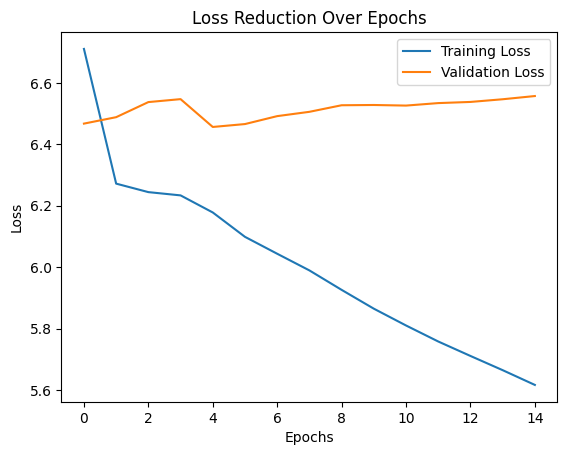

In [17]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Reduction Over Epochs")
plt.legend()
plt.show()

Text Generation Function

In [18]:
def generate_text(seed_text, next_words=60):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len - 1,
            padding="pre"
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0), axis=-1
        )

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                seed_text += " " + word
                break

    return seed_text


Generate Output (3 Seeds)

In [19]:
print(generate_text("harry : i think", 70))
print()
print(generate_text("hermione : this spell", 70))
print()
print(generate_text("voldemort : you will", 70))


harry : i think you a stone of the stone of the stone of the stone of the stone of the stone of of of of of of of of of of of of of of of of reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo of reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo of of of

hermione : this spell you a stone of the stone of the stone of the stone of the stone of the stone of of of of of of of of of of of of of of of of reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo of reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo of of of

voldemort : you will a stone of the stone of the stone of the stone of the stone of of of of of of of of of of of of of of of of of of of of reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo reparo

Observation (For Report)


The LSTM-based text generation model successfully learned sequential language patterns from the Harry Potter dataset. Generated text reflects character-based dialogue, wizarding vocabulary, and narrative flow. Training loss decreased across epochs, indicating effective learning.

